In [ ]:
!pip install -U sympy
!pip install mido

from google.colab import drive
drive.mount('/content/drive/')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 96.3 MB/s eta 0:00:00
  Attempting uninstall: sympy
    Found existing installation: sympy 1.13.1
    Uninstalling sympy-1.13.1:
      Successfully uninstalled sympy-1.13.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cuda-cupti-cu12 12.5.82 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-nvrtc-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cuda-nvrtc-cu12 12.5.82 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cud

Create a dataset - if not loading the dataset from drive, can create new dataset 

In [ ]:
""" TO CREATE DATASET
ds_train = MIDI_DATASET.create_dataset(path="maestro-v3.0.0-midi/maestro-v3.0.0/2018", length=64, output_file="maestro_dataset_for_train_and_validation")
ds_test = MIDI_DATASET.create_dataset(path="maestro-v3.0.0-midi/testing_songs", length=64, output_file="maestro_dataset_for_test")
ds_test.save_dataset_as_midi(folder_path="maestro-v3.0.0-midi/testing_songs_midi/")
"""

' TO CREATE DATASET\nds_train = MIDI_DATASET.create_dataset(path="maestro-v3.0.0-midi/maestro-v3.0.0/2018", length=64, output_file="maestro_dataset_for_train_and_validation")\nds_test = MIDI_DATASET.create_dataset(path="maestro-v3.0.0-midi/testing_songs", length=64, output_file="maestro_dataset_for_test")\nds_test.save_dataset_as_midi(folder_path="maestro-v3.0.0-midi/testing_songs_midi/")\n'

Import dataset for training and validation. 
The split is 85% train and 15% validation. 

In [ ]:
import MIDI_DATASET
dataset = MIDI_DATASET.load_dataset("dataset/maestro_dataset_for_train_and_validation.pth")
train_ds, validation_ds = dataset.split_train_validation(0.85, 0.15, seed=42)
print(len(train_ds))
print(len(validation_ds))

['MIDI-UnprocessedChamber3MID--AUDIO10R32018wav--1', 'MIDI-UnprocessedChamber3MID--AUDIO10R32018wav--2', 'MIDI-UnprocessedChamber4MID--AUDIO11R32018wav--1', 'MIDI-UnprocessedChamber5MID--AUDIO18R32018wav--1', 'MIDI-UnprocessedChamber6MID--AUDIO20R32018wav--1', 'MIDI-UnprocessedChamber6MID--AUDIO20R32018wav--2', 'MIDI-UnprocessedRecital1-3MID--AUDIO01R12018wav--1', 'MIDI-UnprocessedRecital1-3MID--AUDIO01R12018wav--2', 'MIDI-UnprocessedRecital1-3MID--AUDIO02R12018wav--4', 'MIDI-UnprocessedRecital1-3MID--AUDIO03R12018wav--1', 'MIDI-UnprocessedRecital1-3MID--AUDIO03R12018wav--2', 'MIDI-UnprocessedRecital12MID--AUDIO12R12018wav--3', 'MIDI-UnprocessedRecital13-15MID--AUDIO13R12018wav--2', 'MIDI-UnprocessedRecital13-15MID--AUDIO13R12018wav--3', 'MIDI-UnprocessedRecital13-15MID--AUDIO14R12018wav--1', 'MIDI-UnprocessedRecital13-15MID--AUDIO14R12018wav--2', 'MIDI-UnprocessedRecital13-15MID--AUDIO14R12018wav--3', 'MIDI-UnprocessedRecital13-15MID--AUDIO15R12018wav--1', 'MIDI-UnprocessedRecital13-1

Set device + create multiple models for compare:
Two different models:

1- CNN

2 - Transformers

For each model four types of tests:

1 - regular cross entropy + weighted penalty based on the distance between predicted and true classes

2 - regular cross entropy +  penalty based on the distance between the prediction and the previous target

3 - using regual cross entropy and both weighted penalties 

4 - only using regular cross entropy

In [ ]:
import DL_TRAIN_TEST as train_and_test
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

test_names = [r"_weights_target_1_weight_before_0_cross_entropy", r"_weights_target_0_weight_before_1_cross_entropy",  r"_weights_target_1_weight_before_1_cross_entropy", r"_weights_target_0_weight_before_0_cross_entropy"]
params_test = [(0.1,0), (0,0.1), (0.1,0.1), (0,0)]
test_type = [train_and_test.MODEL_TYPE.CNN, train_and_test.MODEL_TYPE.TRANSFORMER]


cuda


For each model type - setup test class and run train and validation function. At the end of each training, save the model weights and the training results. 

setting up model
finished setting up stem layer
(8, 63, 31)
(8, 63, 31)
(12, 63, 31)
(12, 63, 31)
(16, 63, 31)
(16, 63, 31)
finished setting up body
head input size (16, 63, 31)
channels = 30, h=61, w=29
finished setting up model
finished setting up parameters
running 0/20
Allocated: 1.00 GB
Reserved: 1.01 GB
Train: Loss: 2.587667942047119 for epoch 0
Eval: Loss: 3.5332608222961426 for epoch 0
running 1/20
Allocated: 4.04 GB
Reserved: 5.51 GB
Train: Loss: 1.2985355854034424 for epoch 1
Eval: Loss: 3.6192800998687744 for epoch 1
running 2/20
Allocated: 4.04 GB
Reserved: 5.51 GB
Train: Loss: 0.8574091792106628 for epoch 2
Eval: Loss: 3.7694220542907715 for epoch 2
running 3/20
Allocated: 4.04 GB
Reserved: 5.51 GB
Train: Loss: 0.6587198972702026 for epoch 3
Eval: Loss: 3.6833155155181885 for epoch 3
running 4/20
Allocated: 4.04 GB
Reserved: 5.51 GB
Train: Loss: 0.543655514717102 for epoch 4
Eval: Loss: 3.2058470249176025 for epoch 4
running 5/20
Allocated: 4.04 GB
Reserved: 5.51 GB
Train:

/content/drive/MyDrive/Colab Notebooks/project_full/DL_TRAIN_TEST.py:273: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  training_table = training_table.applymap(


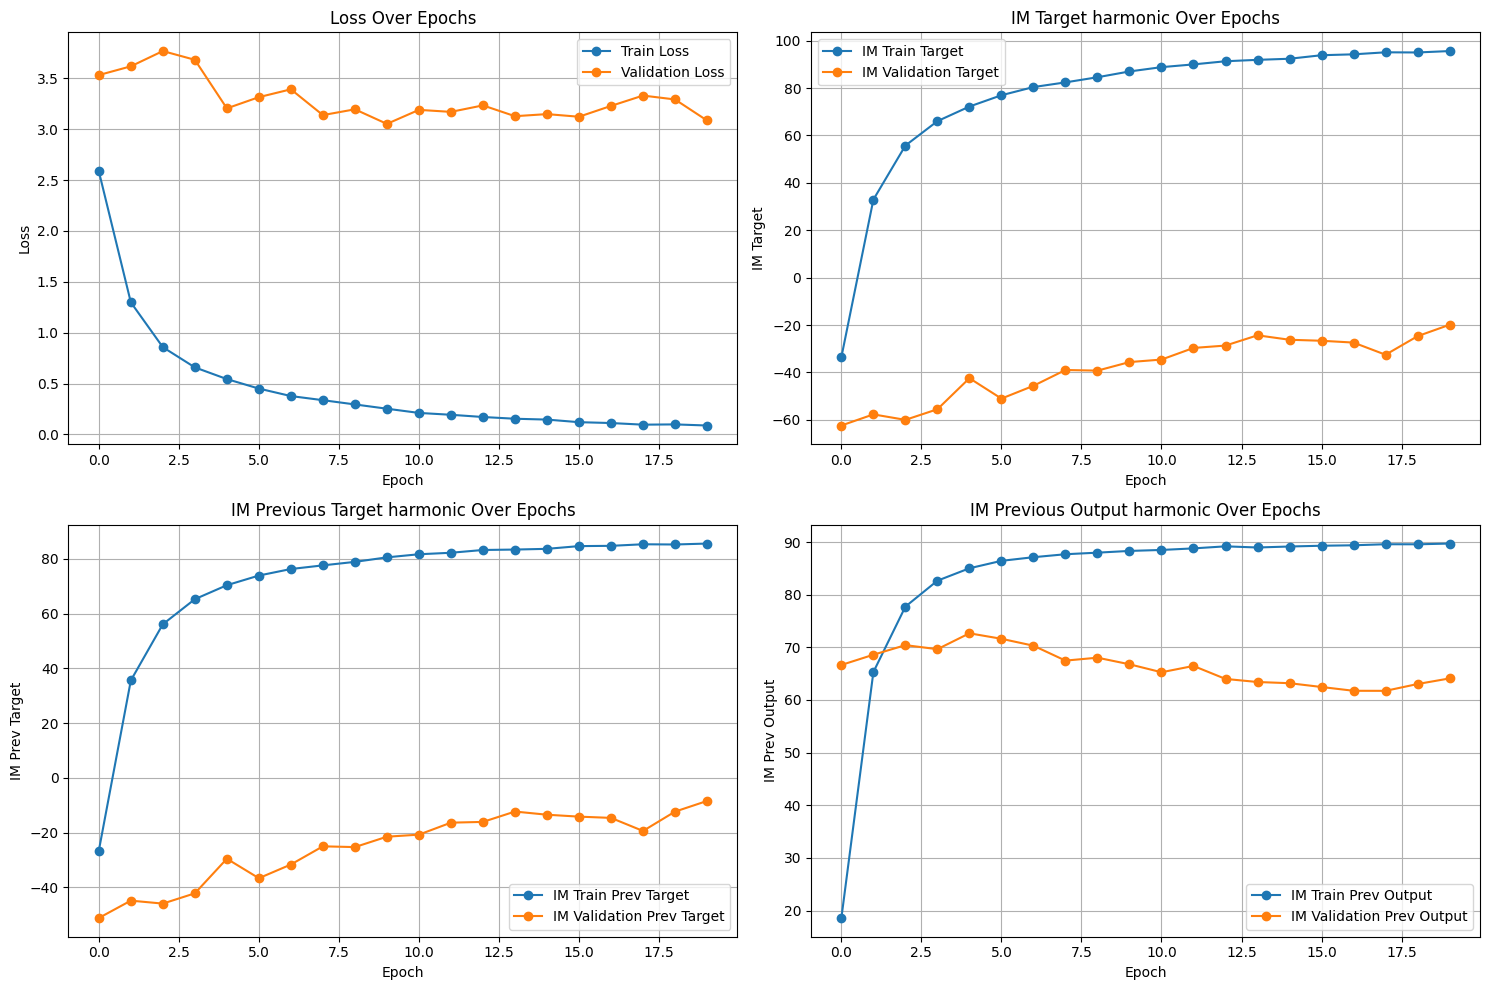

setting up model
finished setting up stem layer
(8, 63, 31)
(8, 63, 31)
(12, 63, 31)
(12, 63, 31)
(16, 63, 31)
(16, 63, 31)
finished setting up body
head input size (16, 63, 31)
channels = 30, h=61, w=29
finished setting up model
finished setting up parameters
running 0/20
Allocated: 1.02 GB
Reserved: 5.51 GB
Train: Loss: 2.530245065689087 for epoch 0
Eval: Loss: 3.5588300228118896 for epoch 0
running 1/20
Allocated: 4.04 GB
Reserved: 5.51 GB
Train: Loss: 1.209428310394287 for epoch 1
Eval: Loss: 3.577462911605835 for epoch 1
running 2/20
Allocated: 4.04 GB
Reserved: 5.51 GB
Train: Loss: 0.8063661456108093 for epoch 2
Eval: Loss: 3.3017232418060303 for epoch 2
running 3/20
Allocated: 4.04 GB
Reserved: 5.51 GB
Train: Loss: 0.632325291633606 for epoch 3
Eval: Loss: 3.1369612216949463 for epoch 3
running 4/20
Allocated: 4.04 GB
Reserved: 5.51 GB
Train: Loss: 0.5415289402008057 for epoch 4
Eval: Loss: 2.895589590072632 for epoch 4
running 5/20
Allocated: 4.04 GB
Reserved: 5.51 GB
Train: Lo

/content/drive/MyDrive/Colab Notebooks/project_full/DL_TRAIN_TEST.py:273: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  training_table = training_table.applymap(


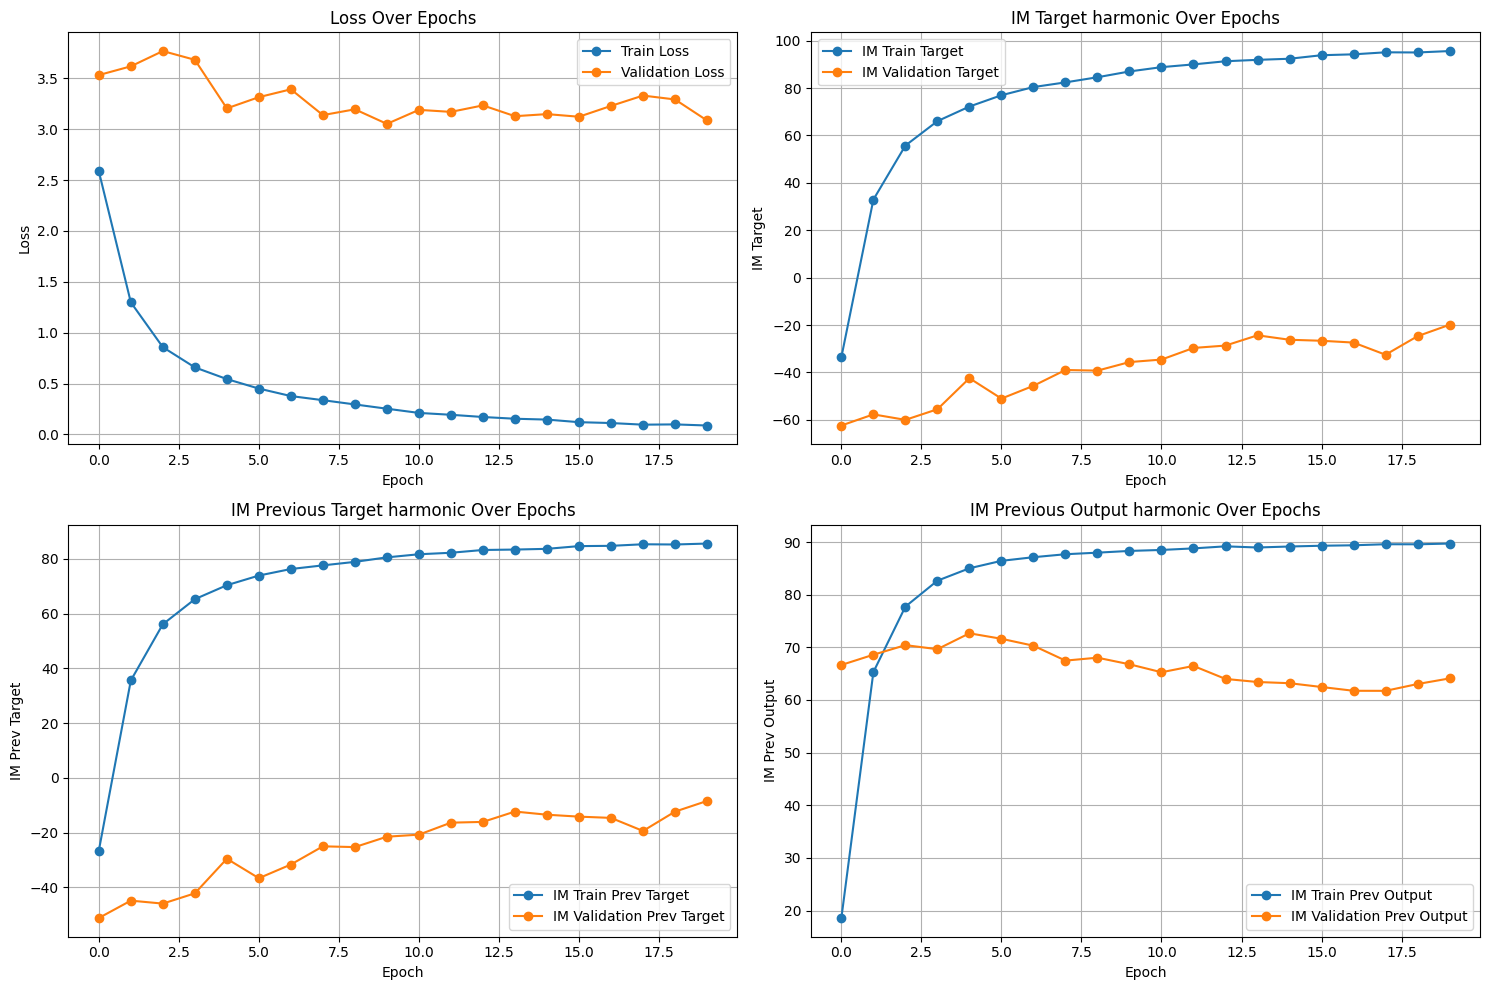

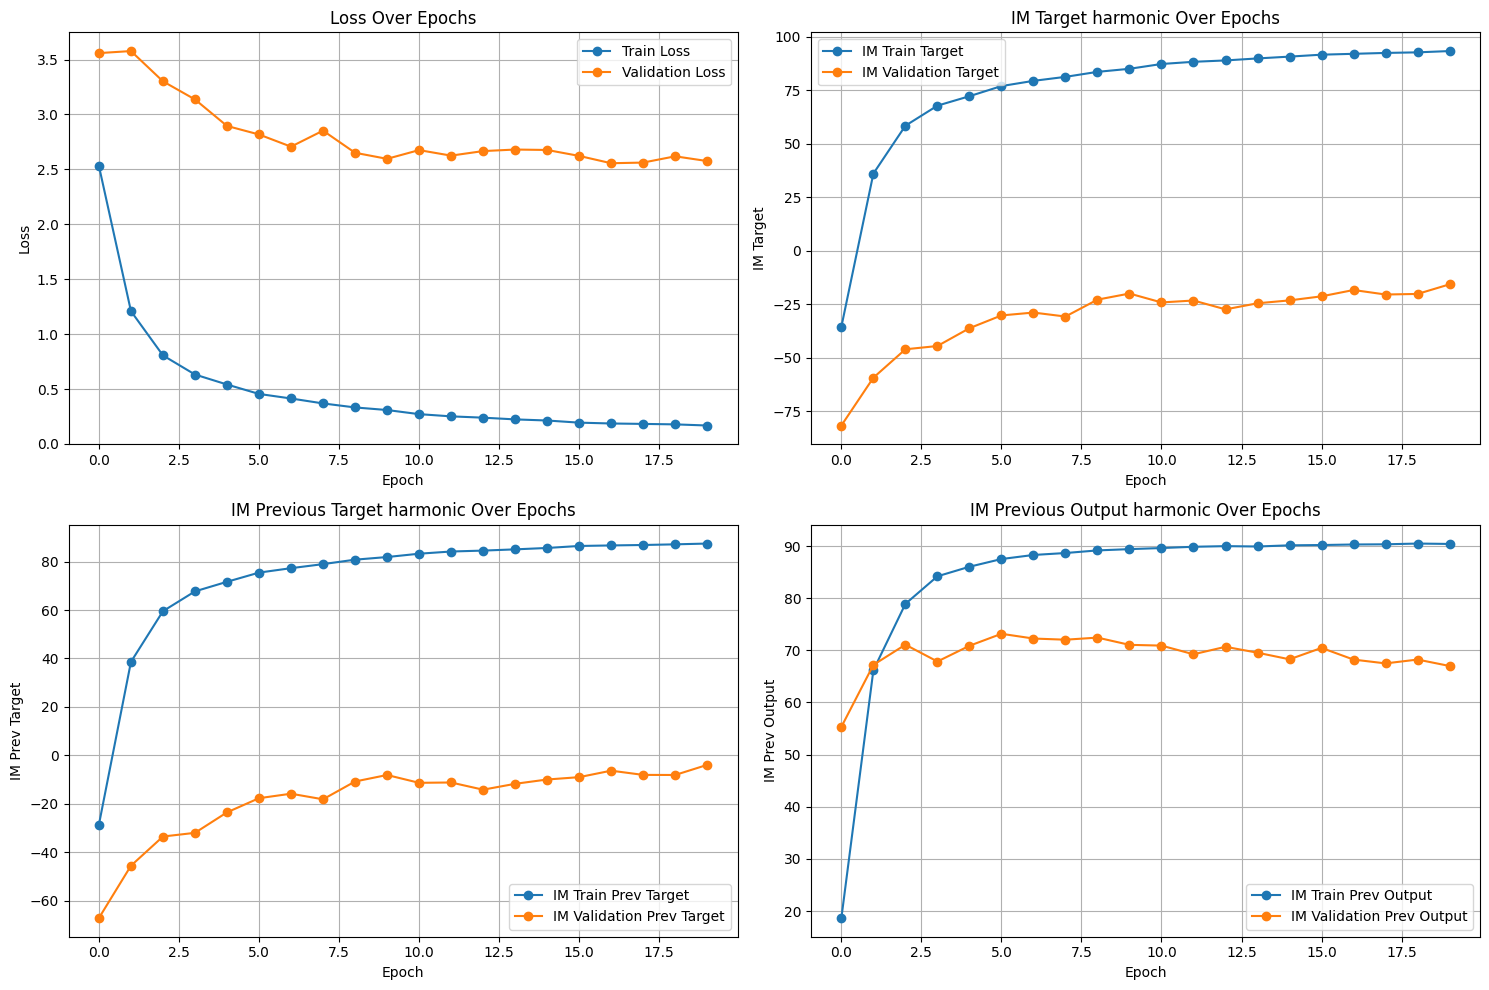

setting up model
finished setting up stem layer
(8, 63, 31)
(8, 63, 31)
(12, 63, 31)
(12, 63, 31)
(16, 63, 31)
(16, 63, 31)
finished setting up body
head input size (16, 63, 31)
channels = 30, h=61, w=29
finished setting up model
finished setting up parameters
running 0/20
Allocated: 1.02 GB
Reserved: 5.51 GB
Train: Loss: 2.9949142932891846 for epoch 0
Eval: Loss: 3.810120105743408 for epoch 0
running 1/20
Allocated: 4.04 GB
Reserved: 5.51 GB
Train: Loss: 1.5490325689315796 for epoch 1
Eval: Loss: 3.7867095470428467 for epoch 1
running 2/20
Allocated: 4.04 GB
Reserved: 5.51 GB
Train: Loss: 0.9927010536193848 for epoch 2
Eval: Loss: 3.6991617679595947 for epoch 2
running 3/20
Allocated: 4.04 GB
Reserved: 5.51 GB
Train: Loss: 0.7867634892463684 for epoch 3
Eval: Loss: 3.345712900161743 for epoch 3
running 4/20
Allocated: 4.04 GB
Reserved: 5.51 GB
Train: Loss: 0.6554140448570251 for epoch 4
Eval: Loss: 3.371450662612915 for epoch 4
running 5/20
Allocated: 4.04 GB
Reserved: 5.51 GB
Train: 

/content/drive/MyDrive/Colab Notebooks/project_full/DL_TRAIN_TEST.py:273: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  training_table = training_table.applymap(


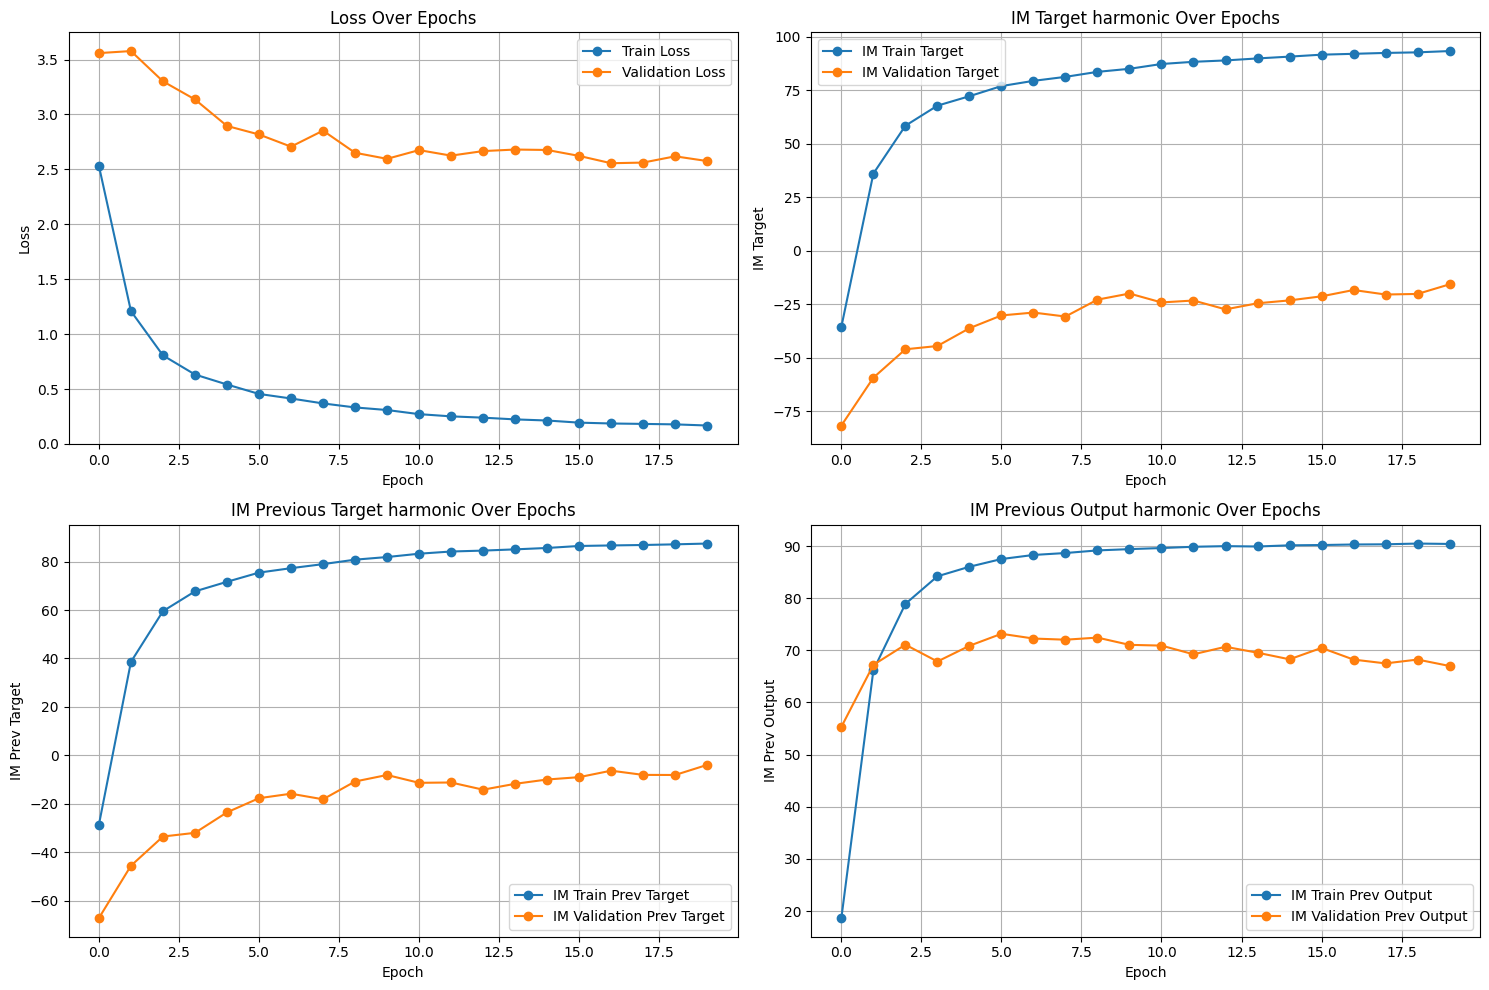

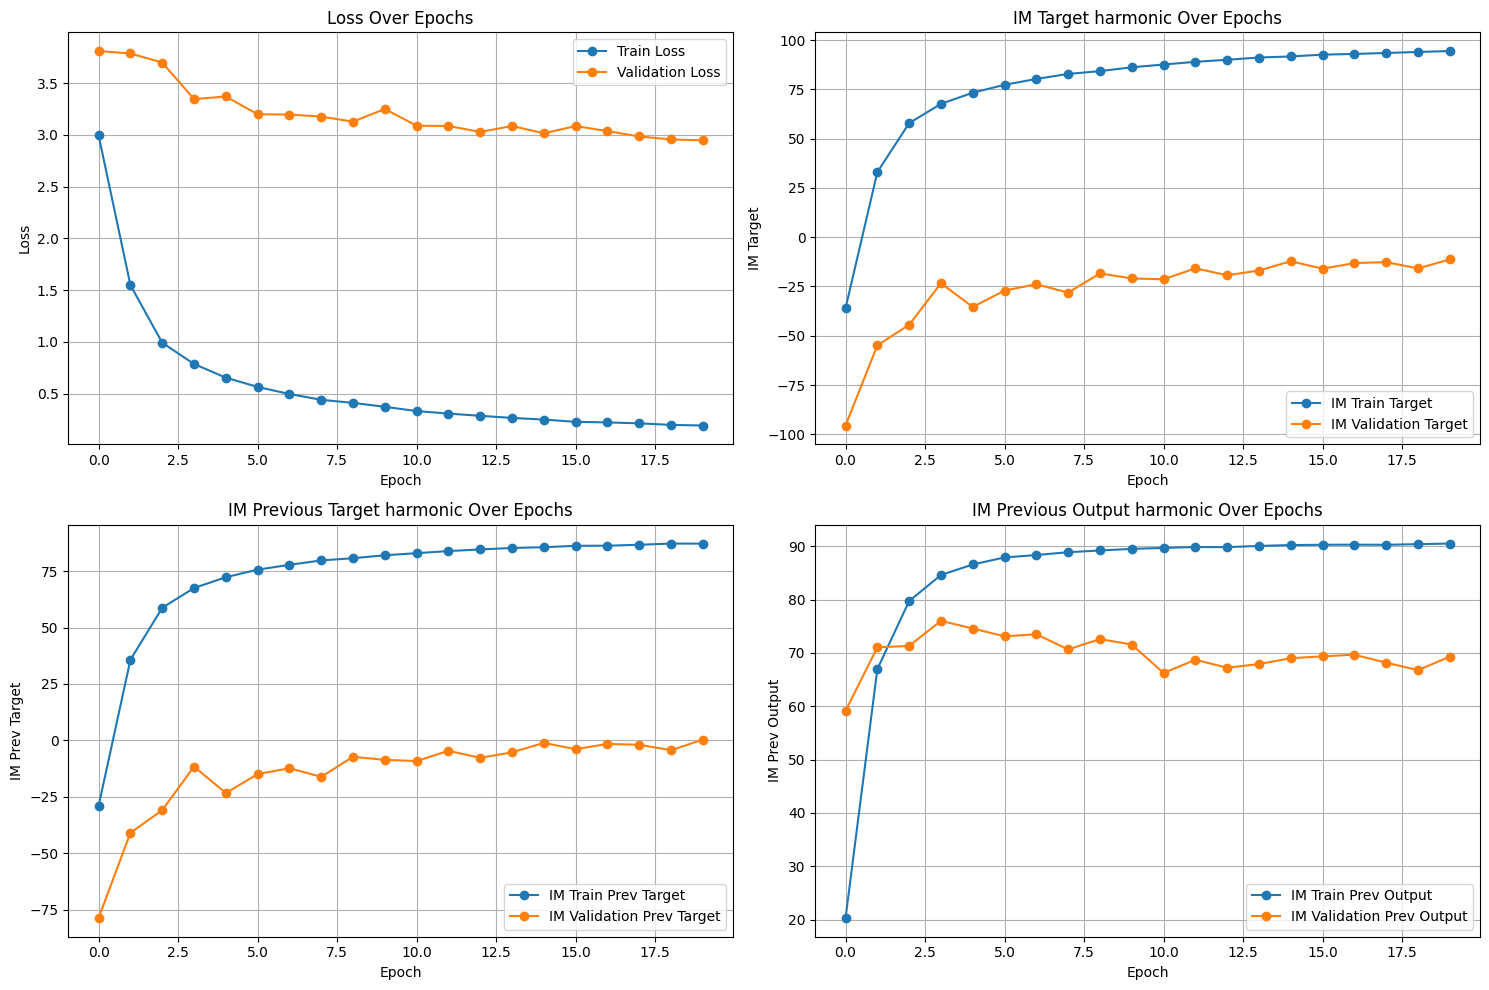

setting up model
finished setting up stem layer
(8, 63, 31)
(8, 63, 31)
(12, 63, 31)
(12, 63, 31)
(16, 63, 31)
(16, 63, 31)
finished setting up body
head input size (16, 63, 31)
channels = 30, h=61, w=29
finished setting up model
finished setting up parameters
running 0/20
Allocated: 1.02 GB
Reserved: 5.51 GB
Train: Loss: 2.0433387756347656 for epoch 0
Eval: Loss: 3.1654539108276367 for epoch 0
running 1/20
Allocated: 4.04 GB
Reserved: 5.51 GB
Train: Loss: 0.7959180474281311 for epoch 1
Eval: Loss: 2.9351894855499268 for epoch 1
running 2/20
Allocated: 4.04 GB
Reserved: 5.51 GB
Train: Loss: 0.5251349210739136 for epoch 2
Eval: Loss: 2.369795560836792 for epoch 2
running 3/20
Allocated: 4.04 GB
Reserved: 5.51 GB
Train: Loss: 0.4007740616798401 for epoch 3
Eval: Loss: 2.394469738006592 for epoch 3
running 4/20
Allocated: 4.04 GB
Reserved: 5.51 GB
Train: Loss: 0.32729649543762207 for epoch 4
Eval: Loss: 2.3560478687286377 for epoch 4
running 5/20
Allocated: 4.04 GB
Reserved: 5.51 GB
Train

/content/drive/MyDrive/Colab Notebooks/project_full/DL_TRAIN_TEST.py:273: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  training_table = training_table.applymap(


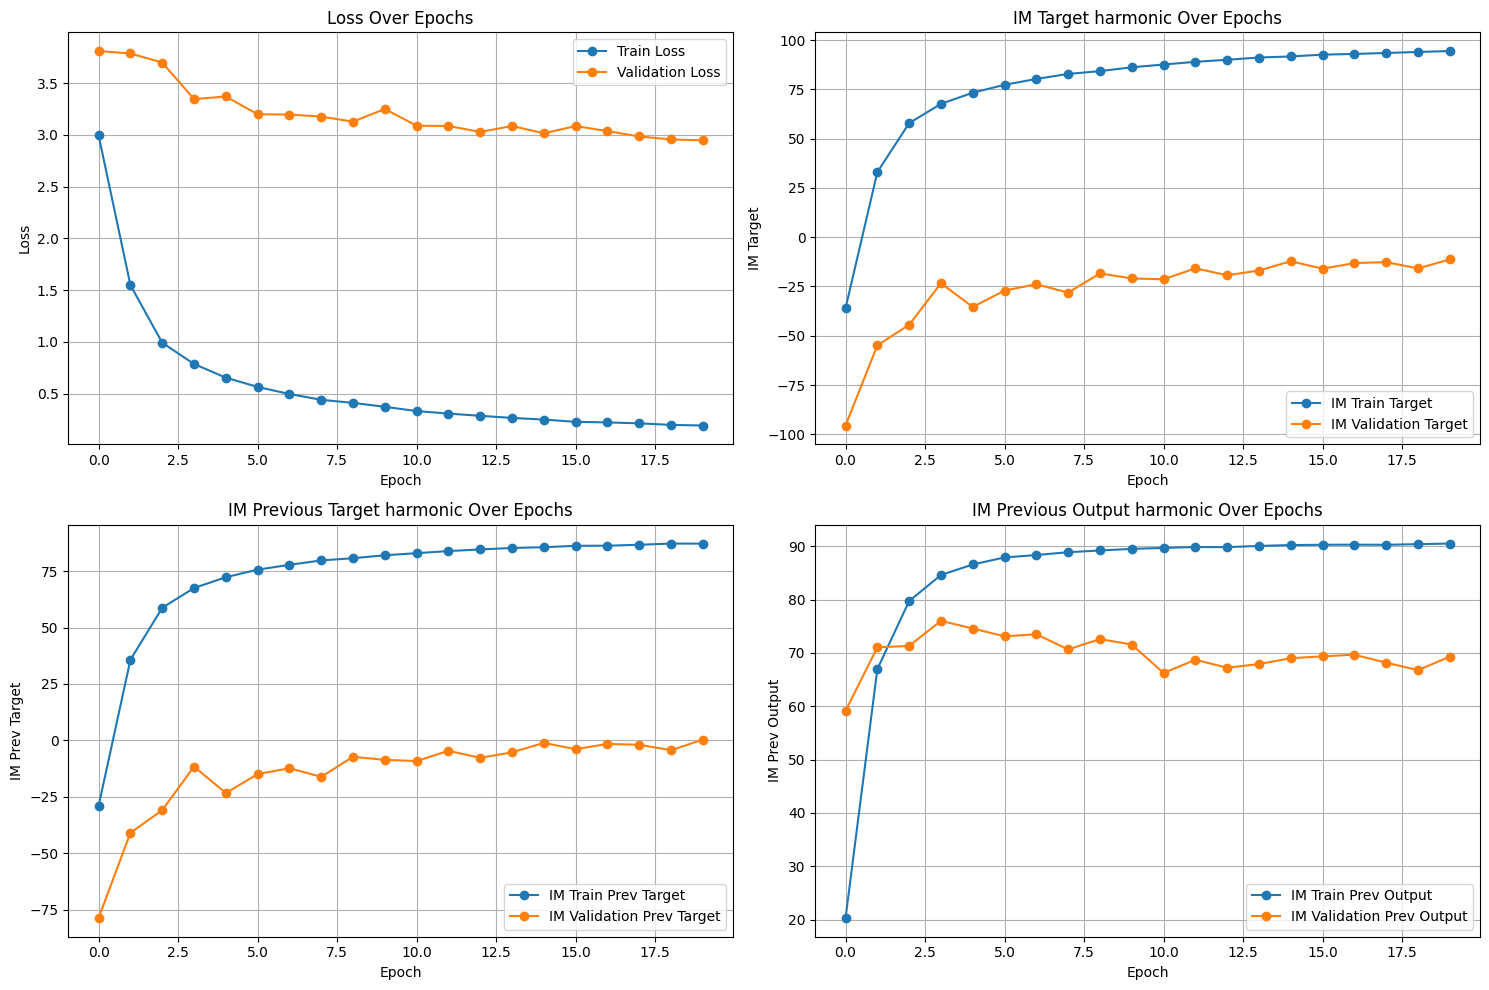

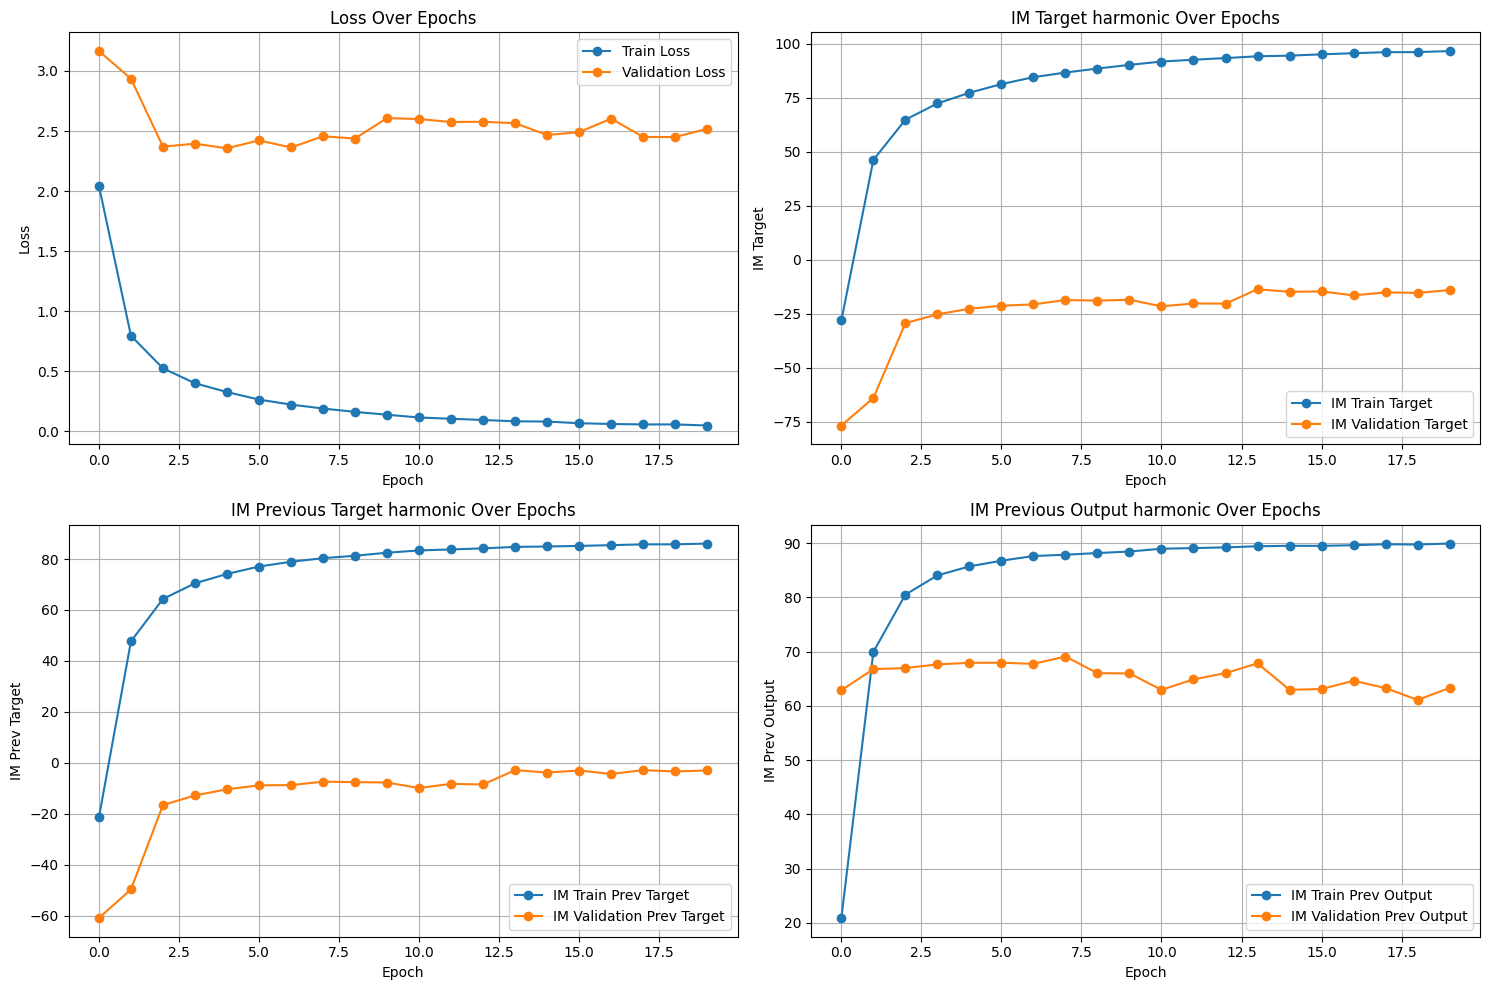

finished setting up parameters
running 0/20
Allocated: 0.07 GB
Reserved: 5.52 GB
Train: Loss: 1.2744399309158325 for epoch 0
Eval: Loss: 1.5042431354522705 for epoch 0
running 1/20
Allocated: 0.22 GB
Reserved: 5.61 GB
Train: Loss: 0.48049697279930115 for epoch 1
Eval: Loss: 1.223184585571289 for epoch 1
running 2/20
Allocated: 0.22 GB
Reserved: 5.61 GB
Train: Loss: 0.404660701751709 for epoch 2
Eval: Loss: 1.1501191854476929 for epoch 2
running 3/20
Allocated: 0.22 GB
Reserved: 5.61 GB
Train: Loss: 0.3592013120651245 for epoch 3
Eval: Loss: 1.3534296751022339 for epoch 3
running 4/20
Allocated: 0.22 GB
Reserved: 5.61 GB
Train: Loss: 0.3286497890949249 for epoch 4
Eval: Loss: 1.373102068901062 for epoch 4
running 5/20
Allocated: 0.22 GB
Reserved: 5.61 GB
Train: Loss: 0.3047778606414795 for epoch 5
Eval: Loss: 1.28170907497406 for epoch 5
running 6/20
Allocated: 0.22 GB
Reserved: 5.61 GB
Train: Loss: 0.290696918964386 for epoch 6
Eval: Loss: 1.486868143081665 for epoch 6
running 7/20
All

/content/drive/MyDrive/Colab Notebooks/project_full/DL_TRAIN_TEST.py:273: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  training_table = training_table.applymap(


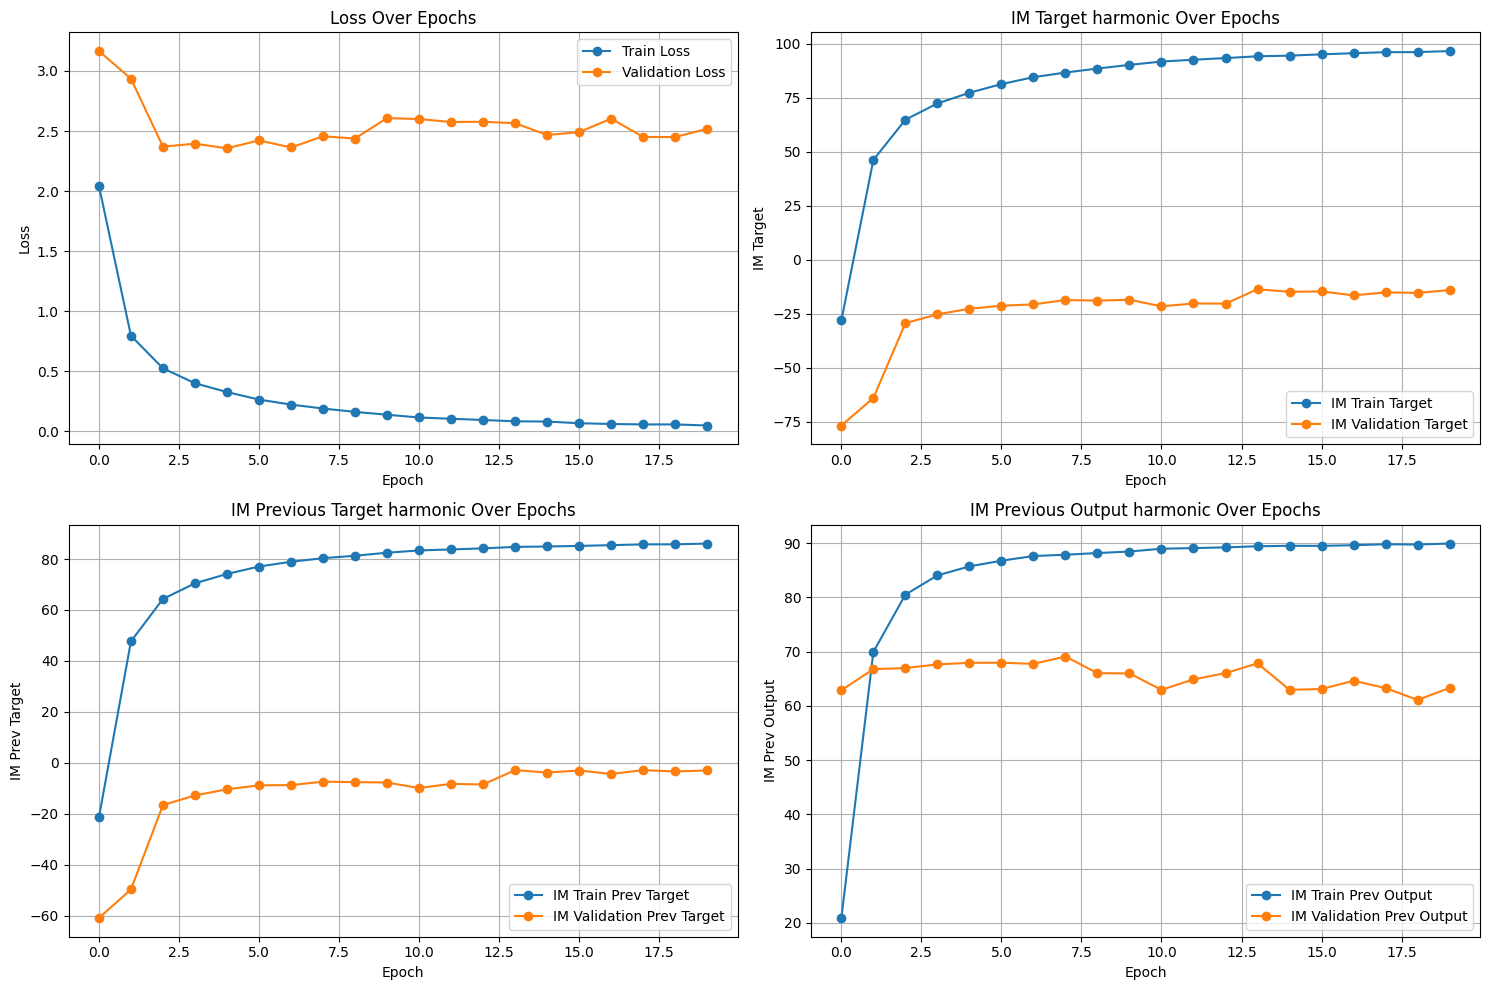

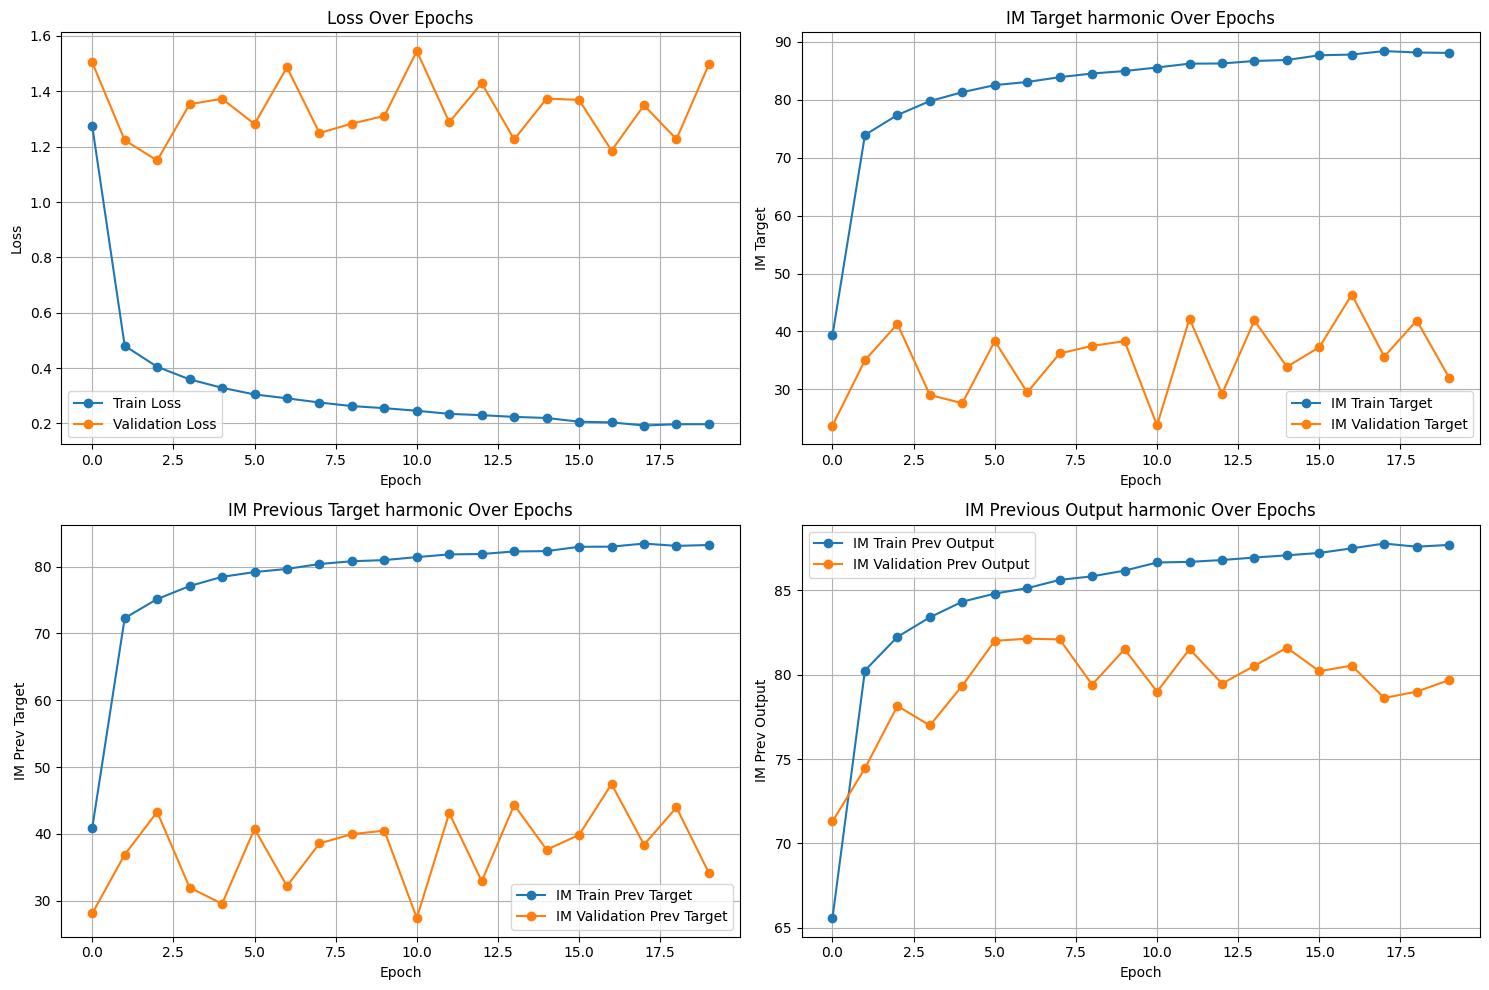

finished setting up parameters
running 0/20
Allocated: 0.17 GB
Reserved: 5.61 GB
Train: Loss: 1.3092074394226074 for epoch 0
Eval: Loss: 1.5762109756469727 for epoch 0
running 1/20
Allocated: 0.22 GB
Reserved: 5.65 GB
Train: Loss: 0.4943545460700989 for epoch 1
Eval: Loss: 1.3187828063964844 for epoch 1
running 2/20
Allocated: 0.22 GB
Reserved: 5.65 GB
Train: Loss: 0.4171268045902252 for epoch 2
Eval: Loss: 1.1893821954727173 for epoch 2
running 3/20
Allocated: 0.22 GB
Reserved: 5.65 GB
Train: Loss: 0.3773069381713867 for epoch 3
Eval: Loss: 1.2494581937789917 for epoch 3
running 4/20
Allocated: 0.22 GB
Reserved: 5.65 GB
Train: Loss: 0.3515888452529907 for epoch 4
Eval: Loss: 1.2280216217041016 for epoch 4
running 5/20
Allocated: 0.22 GB
Reserved: 5.65 GB
Train: Loss: 0.3236463665962219 for epoch 5
Eval: Loss: 1.0688965320587158 for epoch 5
running 6/20
Allocated: 0.22 GB
Reserved: 5.65 GB
Train: Loss: 0.30612269043922424 for epoch 6
Eval: Loss: 1.330224633216858 for epoch 6
running 7/

/content/drive/MyDrive/Colab Notebooks/project_full/DL_TRAIN_TEST.py:273: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  training_table = training_table.applymap(


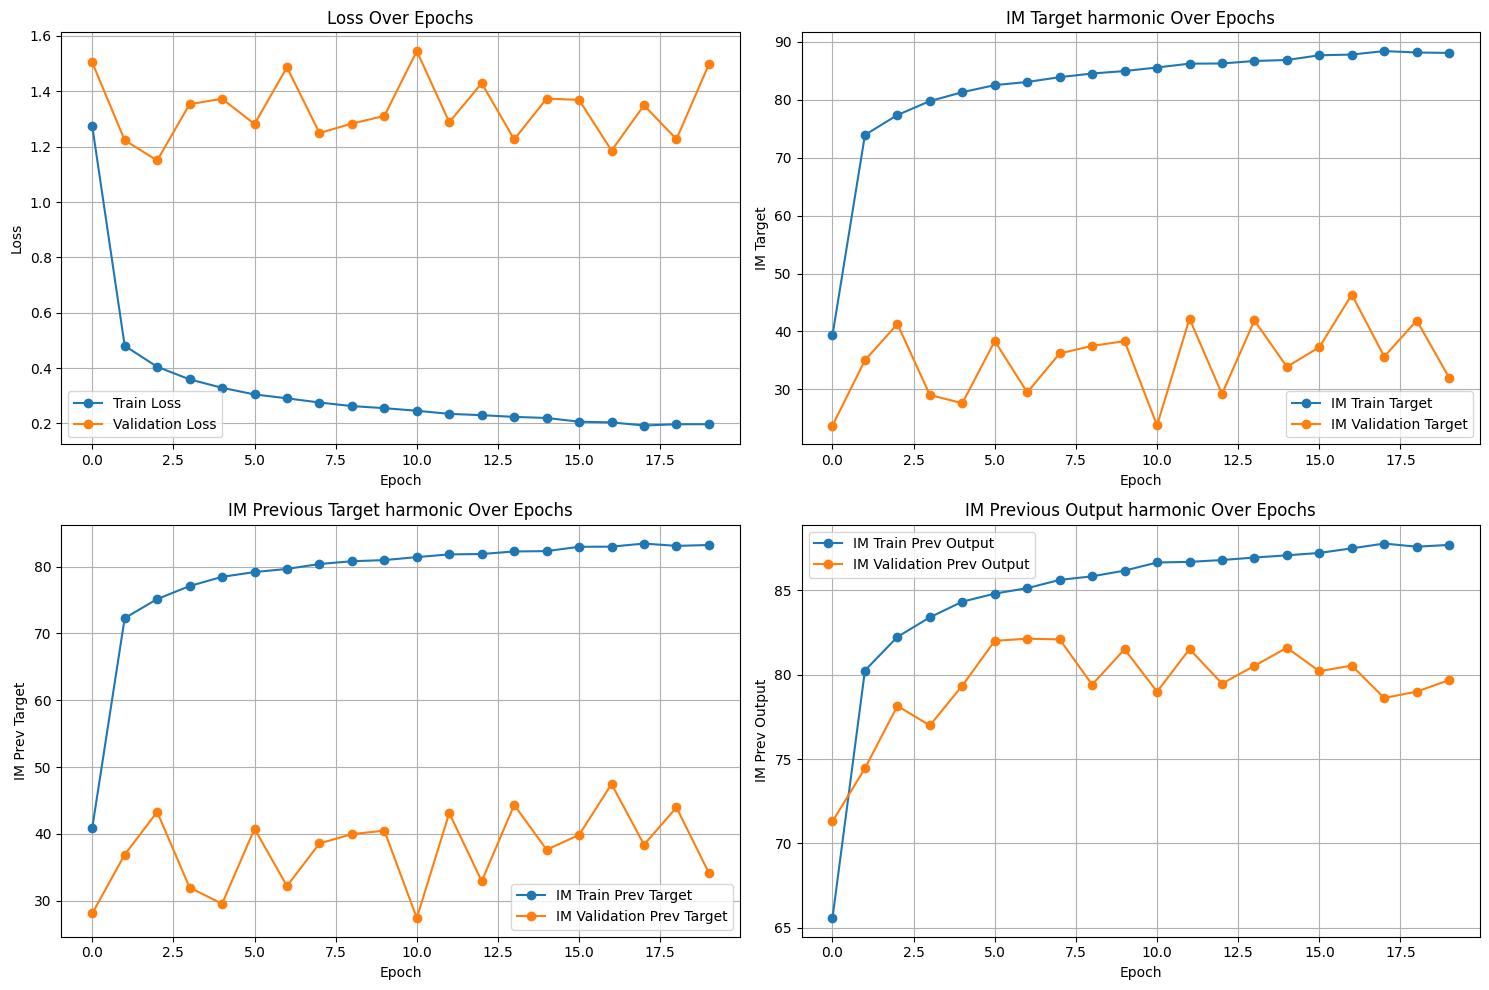

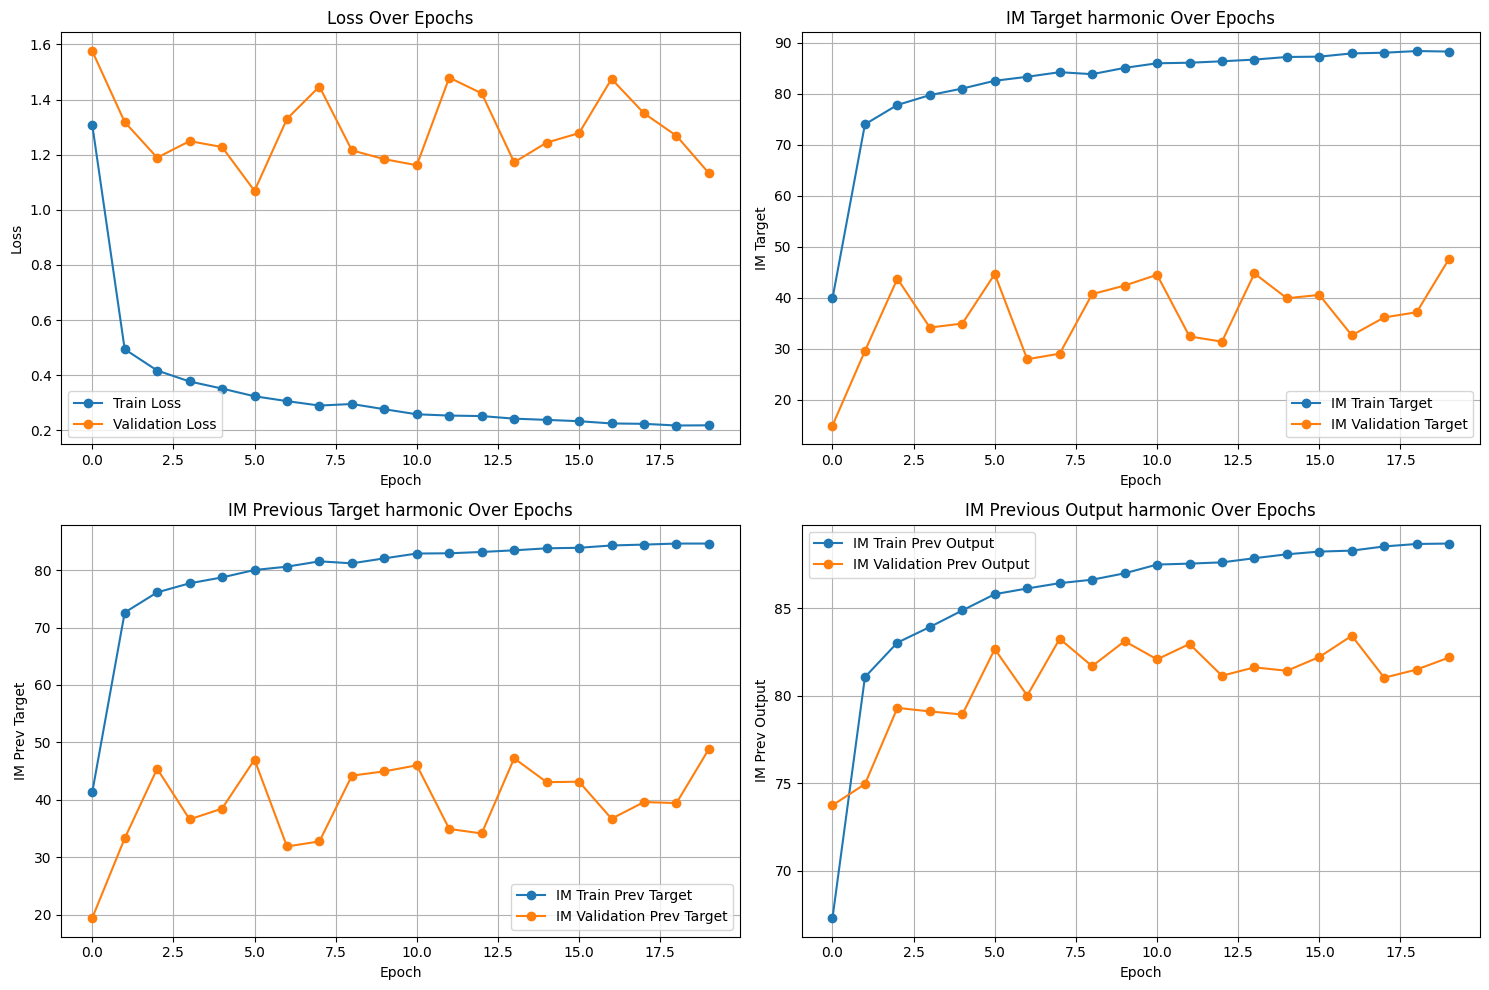

finished setting up parameters
running 0/20
Allocated: 0.17 GB
Reserved: 5.65 GB
Train: Loss: 1.5149091482162476 for epoch 0
Eval: Loss: 1.73137629032135 for epoch 0
running 1/20
Allocated: 0.23 GB
Reserved: 5.65 GB
Train: Loss: 0.6337560415267944 for epoch 1
Eval: Loss: 1.6239339113235474 for epoch 1
running 2/20
Allocated: 0.23 GB
Reserved: 5.65 GB
Train: Loss: 0.5403013825416565 for epoch 2
Eval: Loss: 1.469365119934082 for epoch 2
running 3/20
Allocated: 0.23 GB
Reserved: 5.65 GB
Train: Loss: 0.48262983560562134 for epoch 3
Eval: Loss: 1.6936970949172974 for epoch 3
running 4/20
Allocated: 0.23 GB
Reserved: 5.65 GB
Train: Loss: 0.45496881008148193 for epoch 4
Eval: Loss: 1.674048662185669 for epoch 4
running 5/20
Allocated: 0.23 GB
Reserved: 5.65 GB
Train: Loss: 0.4191320240497589 for epoch 5
Eval: Loss: 1.4961742162704468 for epoch 5
running 6/20
Allocated: 0.23 GB
Reserved: 5.65 GB
Train: Loss: 0.4028052091598511 for epoch 6
Eval: Loss: 1.5280834436416626 for epoch 6
running 7/20

/content/drive/MyDrive/Colab Notebooks/project_full/DL_TRAIN_TEST.py:273: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  training_table = training_table.applymap(


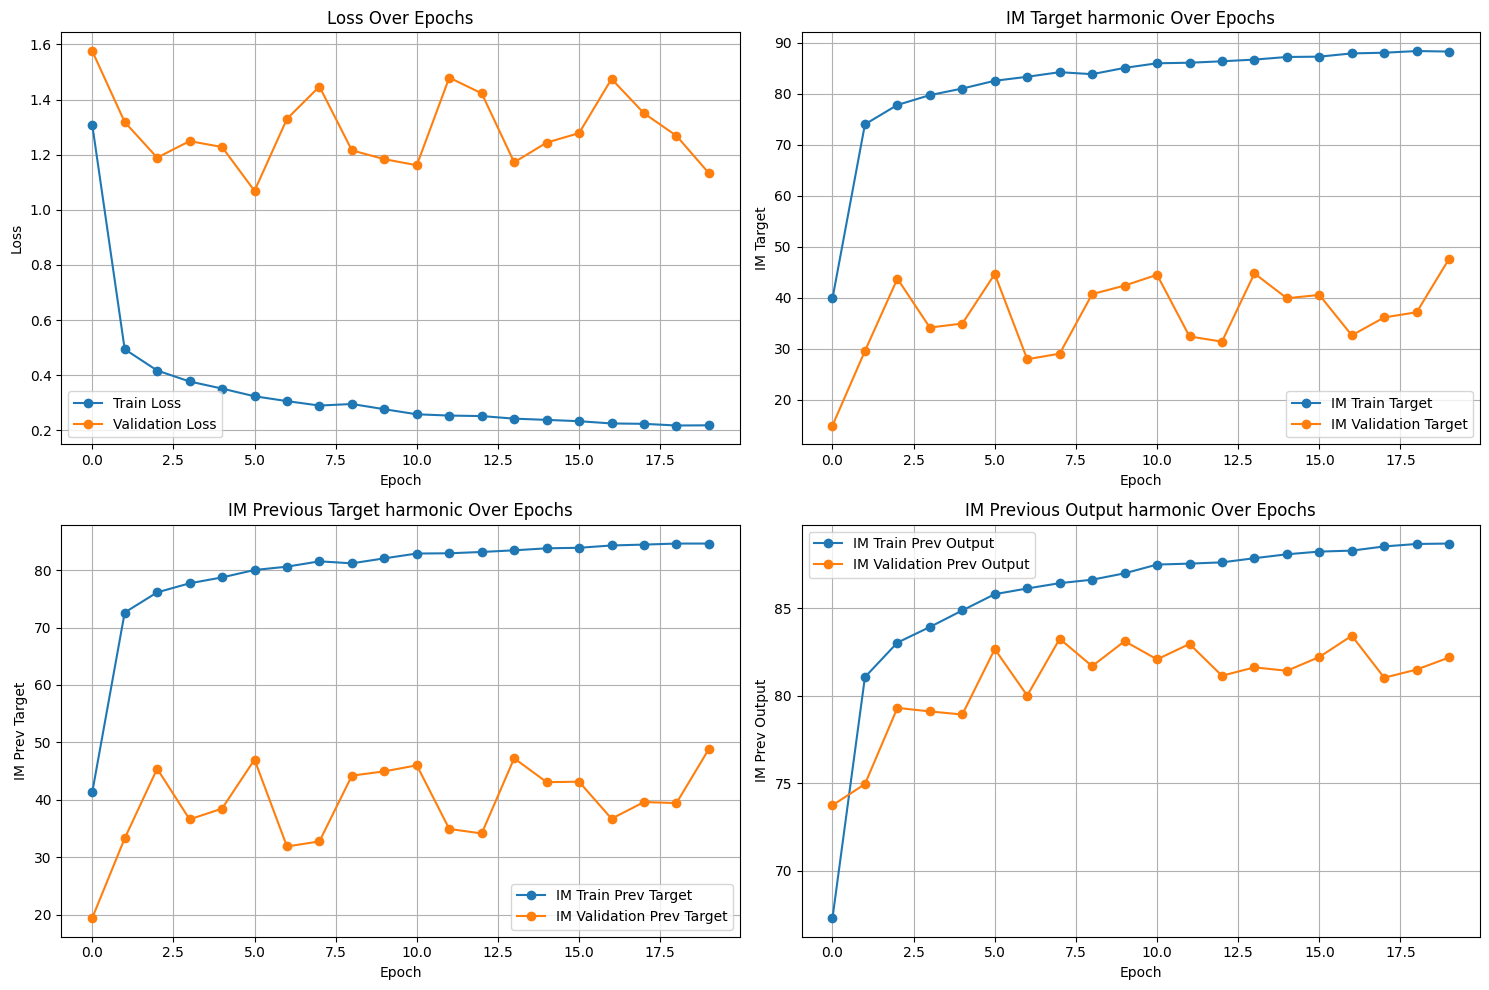

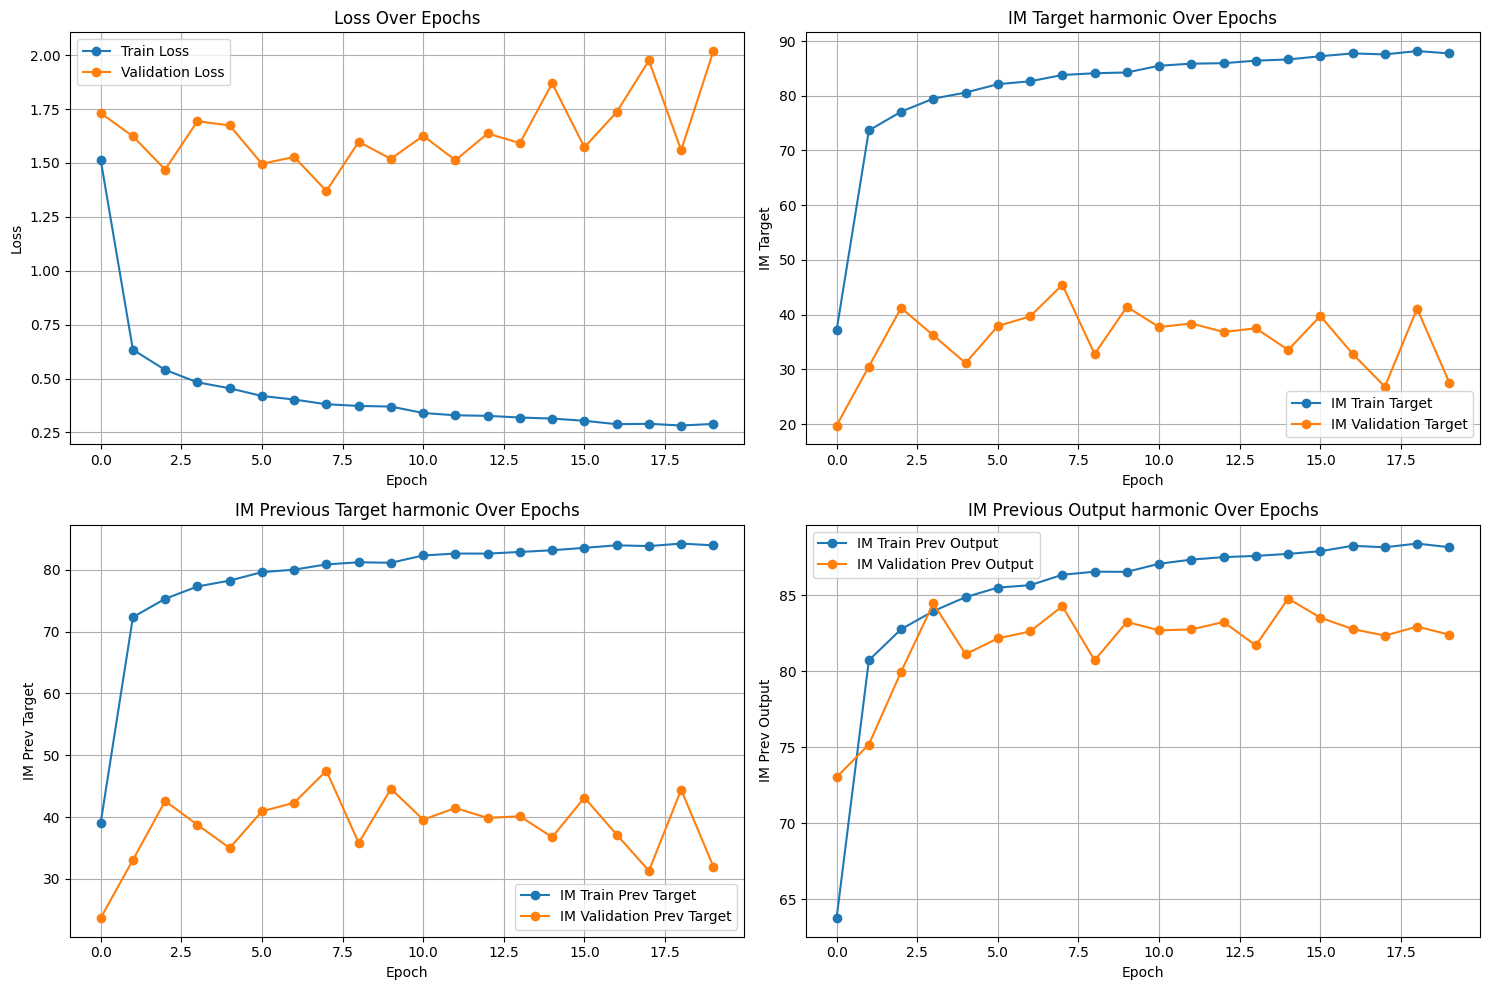

finished setting up parameters
running 0/20
Allocated: 0.17 GB
Reserved: 5.65 GB
Train: Loss: 1.0807677507400513 for epoch 0
Eval: Loss: 0.8993637561798096 for epoch 0
running 1/20
Allocated: 0.22 GB
Reserved: 5.65 GB
Train: Loss: 0.3447408080101013 for epoch 1
Eval: Loss: 0.9238506555557251 for epoch 1
running 2/20
Allocated: 0.22 GB
Reserved: 5.65 GB
Train: Loss: 0.28721538186073303 for epoch 2
Eval: Loss: 0.8337720036506653 for epoch 2
running 3/20
Allocated: 0.22 GB
Reserved: 5.65 GB
Train: Loss: 0.2580321431159973 for epoch 3
Eval: Loss: 0.8673195242881775 for epoch 3
running 4/20
Allocated: 0.22 GB
Reserved: 5.65 GB
Train: Loss: 0.2311280369758606 for epoch 4
Eval: Loss: 0.9836445450782776 for epoch 4
running 5/20
Allocated: 0.22 GB
Reserved: 5.65 GB
Train: Loss: 0.21744513511657715 for epoch 5
Eval: Loss: 1.0423696041107178 for epoch 5
running 6/20
Allocated: 0.22 GB
Reserved: 5.65 GB
Train: Loss: 0.20243795216083527 for epoch 6
Eval: Loss: 0.8737531304359436 for epoch 6
running

In [ ]:
for t in test_type:
  for i, tests in enumerate(test_names):
    trainer = train_and_test.Train(model_type=t, path=r"train_and_test5/{0}{1}".format(t,tests), validation_set =validation_ds, training_set=train_ds, device = device )
    if(t ==train_and_test.MODEL_TYPE.CNN):
      trainer.set_model(
          seq_len=64,
          dropout=0.5,
          dropout_depth=0.2
      )
    if(t ==train_and_test.MODEL_TYPE.TRANSFORMER):
      trainer.set_model(
        seq_len=64,
        dropout=0.5,
        hidden_dim = 512,
        num_encoder_layers = 4,
        num_decoder_layers=2
        )
    trainer.set_training_params(
        lr_step= 8,
        lr_start= 5e-4,
        lr_mul=0.5,
        batch_size=32,
        patience = 5,
        with_eval_set =True
    )
    trainer.set_loss_function(weights_target=params_test[i][0], weights_before=params_test[i][1])
    trainer.train(epoch_size=20)
    trainer.save_model_weights()
    trainer.save_training()

Compare all the training results in one plot. 

<ipython-input-1-311bac2c2ac8>:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(labels))


FileNotFoundError: [Errno 2] No such file or directory: 'train_and_test4/MODEL_TYPE.CNN_weights_target_0_weight_before_0_cross_entropy.csv'

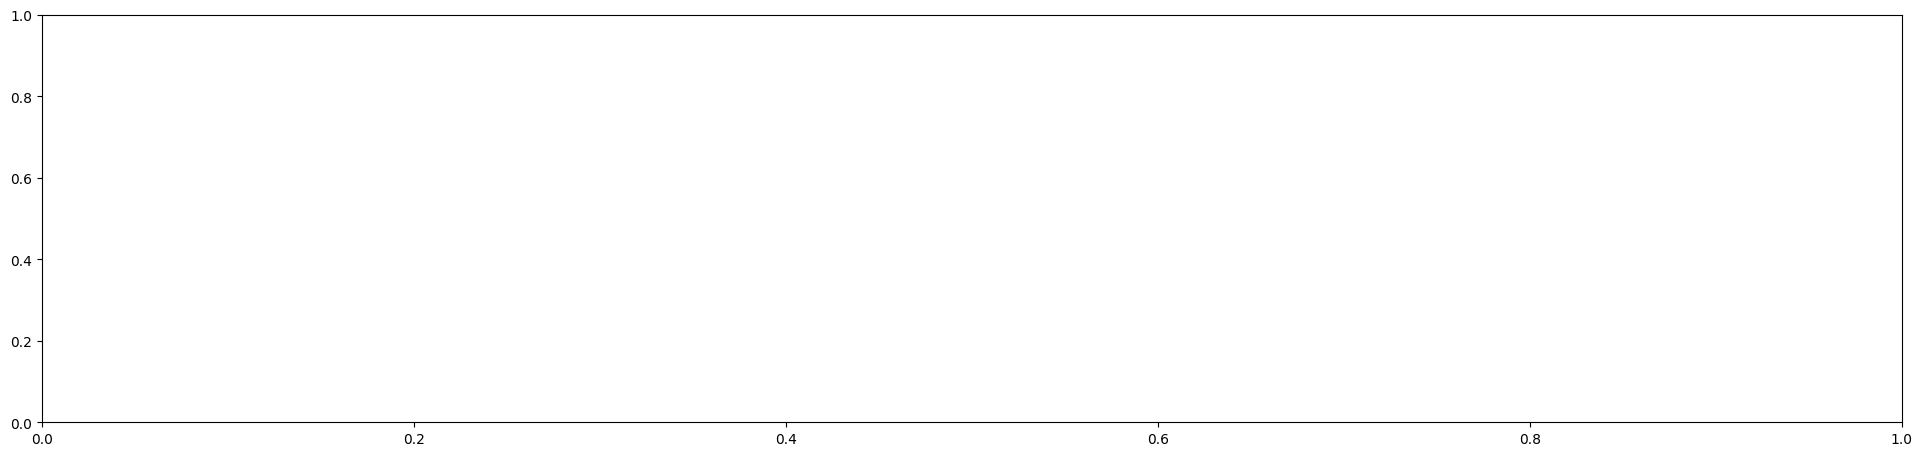

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_multiple_runs(csv_paths, labels):
    """
    Plots training results from multiple CSV files on the same graph.

    Parameters:
    - csv_paths: list of paths to CSV files
    - labels: list of labels corresponding to each CSV
    """
    assert len(csv_paths) == len(labels), "Each CSV must have a corresponding label"

    plt.figure(figsize=(24, 18))

    subplot_titles = [
        ('im train target', 'im valid target', 'IM Target', 'IM Target harmonic Over Epochs'),
        ('im train prev target', 'im valid prev target', 'IM Prev Target', 'IM Previous Target harmonic Over Epochs'),
        ('im train prev output', 'im valid prev output', 'IM Prev Output', 'IM Previous Output harmonic Over Epochs')
    ]

    colors = plt.cm.get_cmap('tab10', len(labels))

    for i, (col1, col2, ylabel, title) in enumerate(subplot_titles, 1):
      plt.subplot(3, 1, i)
      for j, (path, label) in enumerate(zip(csv_paths, labels)):
          table = pd.read_csv(path, index_col=0)
          table = table.applymap(lambda x: x.detach().cpu().item() if torch.is_tensor(x) else x)
          epochs = table.index

          color = colors(j)
          plt.plot(epochs, table[col1], label=f'{label} - train', color=color, linestyle='-')
          plt.plot(epochs, table[col2], label=f'{label} - val', color=color, linestyle='--')

      plt.xlabel('Epoch')
      plt.ylabel(ylabel)
      plt.title(title)
      plt.legend()
      plt.grid(True)

    plt.tight_layout()
    plt.show()

csv_paths = [
    "train_and_test4/MODEL_TYPE.CNN_weights_target_0_weight_before_0_cross_entropy.csv",
    "train_and_test4/MODEL_TYPE.CNN_weights_target_0_weight_before_1_cross_entropy.csv",
    "train_and_test4/MODEL_TYPE.CNN_weights_target_1_weight_before_0_cross_entropy.csv",
    "train_and_test4/MODEL_TYPE.CNN_weights_target_1_weight_before_1_cross_entropy.csv",
    "train_and_test4/MODEL_TYPE.TRANSFORMER_weights_target_1_weight_before_0_cross_entropy.csv",
    "train_and_test4/MODEL_TYPE.TRANSFORMER_weights_target_0_weight_before_1_cross_entropy.csv",
    "train_and_test4/MODEL_TYPE.TRANSFORMER_weights_target_1_weight_before_1_cross_entropy.csv",
     "train_and_tes43/MODEL_TYPE.TRANSFORMER_weights_target_0_weight_before_0_cross_entropy.csv"
]

labels = [
    "CNN_weights_target_0_weight_before_0",
    "CNN_weights_target_0_weight_before_1",
    "CNN_weights_target_1_weight_before_0",
    "CNN_weights_target_1_weight_before_1",
    "TRANSFORMER_weights_target_1_weight_before_0",
    "TRANSFORMER_weights_target_0_weight_before_1",
    "TRANSFORMER_weights_target_1_weight_before_1",
    "TRANSFORMER_weights_target_0_weight_before_0"
]

plot_multiple_runs(csv_paths, labels)



Load the test set + for each of the test run the test set. 
The test results is save to the file "train_and_test4/results.csv"

In [ ]:
import DL_TRAIN_TEST as train_and_test
import torch
import MIDI_DATASET
train_dataset = MIDI_DATASET.load_test_dataset("dataset/maestro_dataset_for_test.pth")

for t in test_type:
  for i, tests in enumerate(test_names):
      test = train_and_test.Test(device, path = "train_and_test4/{0}{1}".format(t,tests))
      test.load_model(model_type=t, sequence_len=64, hidden_dim=512, decoder_layers=2, encoder_layers=4)
      test.test_multiple_from_dataset(test_dataset=train_dataset)
      test.save_test_results(test_name="{0}{1}".format(t,tests), results_file_path="train_and_test4/results.csv")


setting up model
finished setting up stem layer
(8, 63, 31)
(8, 63, 31)
(12, 63, 31)
(12, 63, 31)
(16, 63, 31)
(16, 63, 31)
finished setting up body
head input size (16, 63, 31)
channels = 30, h=61, w=29
finished setting up model
finished loading model from path train_and_test4/MODEL_TYPE.CNN_weights_target_1_weight_before_0_cross_entropy.pth


UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL DL_TRAIN_TEST.MODEL_TYPE was not an allowed global by default. Please use `torch.serialization.add_safe_globals([MODEL_TYPE])` or the `torch.serialization.safe_globals([MODEL_TYPE])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn more about types accepted by default with w